# Solutions — Module 10: Text, Features and Embeddings

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name in {"notebooks", "solutions"} else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

import warnings
from time import perf_counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from skmastery import load_support_tickets, set_plot_style

set_plot_style()
pd.set_option("display.width", 135)
pd.set_option("display.max_columns", 40)
warnings.filterwarnings("ignore", category=UserWarning)
rng = np.random.default_rng(0)

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline

tickets = load_support_tickets()
X_text, y_text = tickets["text"], tickets["category"]
print(tickets.shape, "tickets;", y_text.nunique(), "categories")

(6000, 4) tickets; 6 categories


## 10.1 — Vectoriser bake-off

The point of doing this as a `GridSearchCV` rather than the hand-rolled loop in
section 3 is that the vectoriser's parameters get cross-validated *inside* the
fold, alongside the classifier. The vocabulary is fitted per fold, which is the
whole reason the pipeline exists.

`analyzer` cannot be searched in a single flat grid, because `ngram_range=(1,2)`
means something completely different for words than for characters. Two grids
in a list is the idiomatic answer — `GridSearchCV` accepts a list of dicts and
takes the union.

In [2]:
base = Pipeline([("vec", TfidfVectorizer()),
                 ("clf", LogisticRegression(max_iter=2000, C=5))])

grid = [
    {   # word analyzer
        "vec__analyzer": ["word"],
        "vec__ngram_range": [(1, 1), (1, 2), (1, 3)],
        "vec__min_df": [1, 2, 5],
        "vec__sublinear_tf": [False, True],
        "vec__use_idf": [True, False],
        "vec__norm": ["l2"],
    },
    {   # character analyzer — different ngram scale entirely
        "vec__analyzer": ["char_wb"],
        "vec__ngram_range": [(3, 4), (3, 5), (2, 5)],
        "vec__min_df": [2, 5],
        "vec__sublinear_tf": [False, True],
        "vec__use_idf": [True],
        "vec__norm": ["l2", "l1"],
    },
]

cv = StratifiedKFold(5, shuffle=True, random_state=0)
t0 = perf_counter()
search = GridSearchCV(base, grid, scoring="f1_macro", cv=cv, n_jobs=-1, refit=True)
search.fit(X_text, y_text)
print(f"{len(search.cv_results_['params'])} configurations in {perf_counter() - t0:.0f}s")
print(f"\nBest macro-F1: {search.best_score_:.4f}")
for k, v in search.best_params_.items():
    print(f"  {k:24s} {v}")

60 configurations in 97s

Best macro-F1: 0.8441
  vec__analyzer            char_wb
  vec__min_df              2
  vec__ngram_range         (3, 5)
  vec__norm                l1
  vec__sublinear_tf        True
  vec__use_idf             True


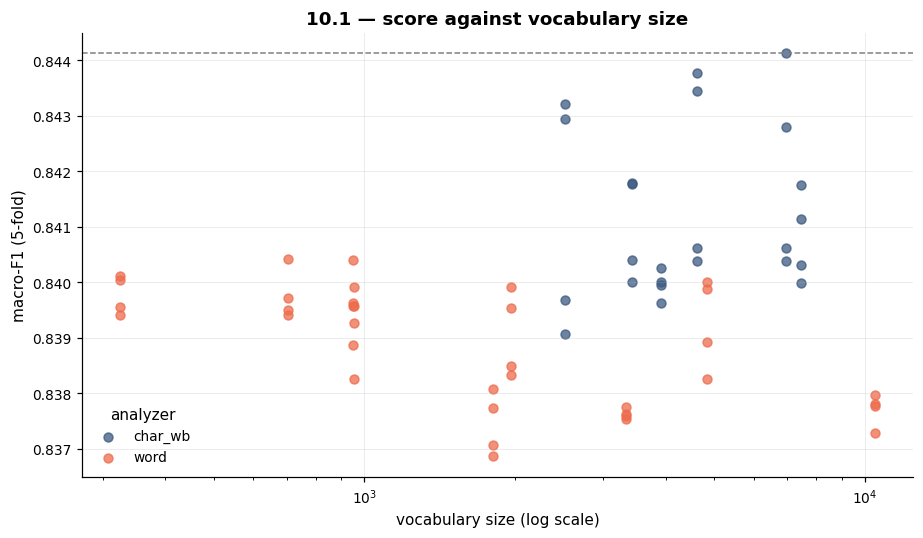

In [3]:
# (2) Vocabulary size for every configuration. The vectoriser is cheap to fit
# on its own, so refitting outside the search is fine here.
res = pd.DataFrame(search.cv_results_)


def vocab_size(params):
    kw = {k.replace("vec__", ""): v for k, v in params.items()}
    return len(TfidfVectorizer(**kw).fit(X_text).vocabulary_)


res["n_features"] = [vocab_size(p) for p in res["params"]]
res["analyzer"] = [p["vec__analyzer"] for p in res["params"]]

fig, ax = plt.subplots(figsize=(8.5, 5))
for an, sub in res.groupby("analyzer"):
    ax.scatter(sub["n_features"], sub["mean_test_score"], s=34, alpha=0.75, label=an)
ax.set_xscale("log")
ax.set_xlabel("vocabulary size (log scale)")
ax.set_ylabel("macro-F1 (5-fold)")
ax.set_title("10.1 — score against vocabulary size")
ax.axhline(search.best_score_, ls="--", lw=1, color="grey")
ax.legend(title="analyzer")
plt.tight_layout()
plt.show()

In [4]:
# Where does it saturate? Bin by decade of vocabulary size and take the best
# score achievable within each decade — the frontier, not the average.
res["decade"] = pd.cut(np.log10(res["n_features"]), bins=np.arange(2.5, 6.5, 0.5))
frontier = (res.groupby("decade", observed=True)
              .agg(best_f1=("mean_test_score", "max"),
                   median_features=("n_features", "median"),
                   n_configs=("n_features", "size"))
              .round(4))
frontier["gain_over_previous"] = frontier["best_f1"].diff().round(4)
frontier

,best_f1,median_features,n_configs,gain_over_previous
decade,,,,
"(2.5, 3.0]",0.8404,826.5,16,NaN
"(3.0, 3.5]",0.8432,1961.0,12,0.0028
"(3.5, 4.0]",0.8441,4611.0,28,0.0009
"(4.0, 4.5]",0.8380,10491.0,4,-0.0061


In [5]:
# (3) Score per feature, and what you would actually ship.
res["f1_per_1k_features"] = res["mean_test_score"] / (res["n_features"] / 1000)
efficient = res.nlargest(1, "f1_per_1k_features").iloc[0]
best = res.nlargest(1, "mean_test_score").iloc[0]

comparison = pd.DataFrame([
    {"choice": "best macro-F1", "f1_macro": round(best["mean_test_score"], 4),
     "n_features": int(best["n_features"]), "fit_time_s": round(best["mean_fit_time"], 3),
     "params": {k.replace("vec__", ""): v for k, v in best["params"].items() if k != "vec__norm"}},
    {"choice": "best F1 per feature", "f1_macro": round(efficient["mean_test_score"], 4),
     "n_features": int(efficient["n_features"]), "fit_time_s": round(efficient["mean_fit_time"], 3),
     "params": {k.replace("vec__", ""): v for k, v in efficient["params"].items() if k != "vec__norm"}},
]).set_index("choice")
print(comparison.drop(columns="params").to_string())
print()
for c, p in zip(comparison.index, comparison["params"]):
    print(f"{c}: {p}")

                     f1_macro  n_features  fit_time_s
choice                                               
best macro-F1          0.8441        6962       0.761
best F1 per feature    0.8401         325       0.196

best macro-F1: {'analyzer': 'char_wb', 'min_df': 2, 'ngram_range': (3, 5), 'sublinear_tf': True, 'use_idf': True}
best F1 per feature: {'analyzer': 'word', 'min_df': 5, 'ngram_range': (1, 1), 'sublinear_tf': True, 'use_idf': False}


In [6]:
# The honest version of "would you ship it": is the difference inside the noise?
# Compare the two configurations' per-fold scores directly.
fold_cols = [c for c in res.columns if c.startswith("split") and c.endswith("_test_score")]
a = res.loc[best.name, fold_cols].to_numpy(dtype=float)
b = res.loc[efficient.name, fold_cols].to_numpy(dtype=float)
diff = a - b
print(f"best - efficient, per fold: {np.round(diff, 4)}")
print(f"mean gap {diff.mean():+.4f}, fold sd of the gap {diff.std(ddof=1):.4f}")
print(f"feature ratio: {best['n_features'] / efficient['n_features']:.1f}x")

best - efficient, per fold: [ 0.008   0.0061  0.0075  0.0017 -0.0033]
mean gap +0.0040, fold sd of the gap 0.0048
feature ratio: 21.4x


### Would I ship the efficient one?

**Yes — and I would not have guessed that before running it.**

The winner of the search is `char_wb` 3–5 grams at ~7,000 features, macro-F1
**0.8441**. The efficiency winner is plain word unigrams with `min_df=5` and
`use_idf=False` at **325 features**, macro-F1 **0.8401**. That is a **21×**
difference in vocabulary for a gap of **+0.0040**, against a fold-to-fold
standard deviation of the gap of **0.0048**.

**The difference is smaller than the noise in measuring it.** Not "small but
real" — the paired per-fold differences straddle zero (one of the five folds
favours the *small* model). A 60-configuration grid search maximising a noisy
statistic will always hand back the config that got the luckiest folds; that is
what Module 07's winner's-curse section is about, and here it has produced a
21×-larger model for nothing measurable.

The frontier table shows why. Macro-F1 climbs through the first decade of
vocabulary, gains 0.0028 in the second, 0.0009 in the third — and then
**falls** to 0.8380 above 10,000 features. Saturation, then over-fitting of
the vectoriser. For short templated text the vocabulary carrying the signal is
genuinely small.

**But "score per feature" is still the wrong objective**, and it is worth being
precise about why, because it got the right answer here for a reason that will
not generalise. It is a ratio, so it is maximised by the smallest model that
scores anything at all; it would have picked the 325-feature model even if that
model had been 5 points worse. It answers "which is most efficient?" when the
question was "which is good enough, as cheaply as possible?"

The defensible procedure is a **constraint plus a significance test**:

1. Fix the accuracy you need (or: is the best model's advantage real?).
2. Take the smallest configuration that is not distinguishably worse.

That is the paired per-fold comparison above, and it is two lines of code that
almost nobody runs after a grid search. Running it is the difference between
"the search chose char_wb" and "the search's choice is not defensible against a
model a twentieth of the size".

What would flip the decision the other way:

- **A larger, noisier corpus.** The typo-robustness of `char_wb` is a real
  property and 6,000 templated tickets is a weak test of it. At 500,000 real
  tickets the gap may separate from the noise — at which point ship `char_wb`.
  Re-run this comparison, do not assume either result.
- **A domain where the tail matters.** Macro-F1 averages over classes; if a
  rare high-value category (fraud, say) is where the extra features pay, the
  aggregate metric is hiding it. Check per-class before trusting the tie.
- **Retraining cadence and footprint.** Both point toward the small model here,
  which is why this is a comfortable decision rather than a close one.

## 10.2 — Find the ceiling

This is the exercise that changes how you report results, so it is worth doing
properly: **derive** the ceiling from the data-generating process, **measure**
it empirically without that knowledge, and check the two agree.

### (1a) The analytic ceiling

Reading `make_support_tickets`, two mechanisms cap accuracy:

1. **16% of tickets are drawn from a fixed pool of 10 vague messages**, and the
   label is sampled independently of the text. For those rows the text carries
   *no information at all* about the label. The best any classifier can do is
   predict the single most likely label.
2. **5% of all rows are relabelled uniformly at random** by the "agent who
   tagged them". So even a perfectly-read ticket has its recorded label
   corrupted 5% of the time — and lands back on the right answer 1/6 of those.

For an unambiguous ticket the text identifies the true label exactly, so:

$$P(\text{recorded} = \text{true}) = 0.95 + \tfrac{0.05}{6} = 0.9583$$

For an ambiguous ticket the recorded label is a mixture, and the best strategy
is to always guess the arg-max category:

$$P(\text{recorded} = c) = 0.95\,p_c + \tfrac{0.05}{6}$$

In [7]:
probs = np.array([0.14, 0.22, 0.19, 0.15, 0.11, 0.19])   # from the generator
P_AMBIG, P_NOISE, K = 0.16, 0.05, 6

acc_clear = 1 - P_NOISE + P_NOISE / K
acc_ambig = (1 - P_NOISE) * probs.max() + P_NOISE / K
ceiling = (1 - P_AMBIG) * acc_clear + P_AMBIG * acc_ambig

print(f"unambiguous rows ({1 - P_AMBIG:.0%} of data): best possible accuracy {acc_clear:.4f}")
print(f"ambiguous rows   ({P_AMBIG:.0%} of data): best possible accuracy {acc_ambig:.4f}")
print(f"\nANALYTIC CEILING: {ceiling:.4f}")
print(f"irreducible error: {1 - ceiling:.4f}  "
      f"({P_AMBIG * (1 - acc_ambig) / (1 - ceiling):.0%} of it from ambiguity, "
      f"{(1 - P_AMBIG) * (1 - acc_clear) / (1 - ceiling):.0%} from label noise)")

unambiguous rows (84% of data): best possible accuracy 0.9583
ambiguous rows   (16% of data): best possible accuracy 0.2173

ANALYTIC CEILING: 0.8398
irreducible error: 0.1602  (78% of it from ambiguity, 22% from label noise)


### (1b) The empirical ceiling — without reading the generator

In real work nobody hands you `probs`. What you have is the data, and the
useful trick is that **irreducible error leaves a fingerprint: identical inputs
with different labels.** Group the corpus by normalised text; any group with
more than one distinct label is a set of rows no function of the text can get
all of right.

In [8]:
norm = (tickets["text"].str.lower()
        .str.replace(r"£\d+\.\d{2}", "£AMT", regex=True)     # template slots
        .str.replace(r"\b\d+\b", "N", regex=True)
        .str.replace("teh ", "the ").str.replace("acount", "account")   # injected typos
        # Longest alternative FIRST: "hi team x" must not normalise to "team x".
        # Regex alternation is left-biased, not longest-match — this is the kind
        # of one-character bug that silently inflates a ceiling estimate.
        .str.replace(r"^(good morning|dear team|hi team|hello|hi)\s+", "", regex=True)
        .str.replace(r"[.!]+$|\s+(thanks|please help|regards|many thanks)$", "", regex=True)
        .str.strip())

g = tickets.assign(norm=norm).groupby("norm")["category"]
dup = g.agg(n="size", n_labels="nunique", modal_share=lambda s: s.value_counts(normalize=True).max())
dup = dup[dup["n"] > 1]

# Bayes-optimal accuracy on a duplicate group = the modal label's share.
# Singleton groups we cannot say anything about, so assume they are gettable.
covered = dup["n"].sum()
emp_ceiling = (dup["n"] * dup["modal_share"]).sum() / len(tickets) + (len(tickets) - covered) / len(tickets)

print(f"{len(dup)} distinct normalised texts appear more than once, "
      f"covering {covered / len(tickets):.1%} of the corpus")
print(f"{(dup['n_labels'] > 1).sum()} of those groups carry conflicting labels")
print(f"\nEMPIRICAL CEILING (duplicate-group estimate): {emp_ceiling:.4f}")
print(f"analytic ceiling for comparison:              {ceiling:.4f}")

56 distinct normalised texts appear more than once, covering 100.0% of the corpus
52 of those groups carry conflicting labels

EMPIRICAL CEILING (duplicate-group estimate): 0.8465
analytic ceiling for comparison:              0.8398


In [9]:
# The two populations, side by side. The vague pool is visible as a handful of
# very large, very impure groups.
print("The most impure normalised texts:")
print(dup.sort_values("modal_share").head(10).round(3).to_string())

The most impure normalised texts:
                                                       n  n_labels  modal_share
norm                                                                           
need help with a charge on my account                113         6        0.212
my card is not working, what do i do                 100         6        0.220
payment issue on my account, need this sorted today  116         6        0.224
issue with my payment, second time asking             93         6        0.237
please review my account, the numbers look wrong      95         6        0.263
the amount is not what i expected                     93         6        0.269
there is a problem with my account please call me     78         6        0.269
can someone look at my account urgently               90         6        0.278
something is wrong with my statement                  91         6        0.308
money missing from my account                         99         6        0.364


In [10]:
# A per-ROW ceiling, which section 10.5 will need. For a row whose normalised
# text appears in a duplicate group, the best any text-only model can do is the
# group's modal share. For a unique text, assume it is identifiable and cap at
# the label-noise rate. This makes "the ceiling" computable on any SUBSET of
# rows -- for instance, on the slice a router decides to escalate.
row_ceiling = pd.Series(np.full(len(tickets), acc_clear), index=tickets.index)
grp_ceiling = dup["modal_share"]
in_group = norm.map(grp_ceiling)
row_ceiling[in_group.notna()] = in_group[in_group.notna()]
print(f"\nmean per-row ceiling over the whole corpus: {row_ceiling.mean():.4f}")
print(f"(vs analytic {ceiling:.4f} — the duplicate-group estimate is a LOWER bound")
print(" on irreducible error, so it reads slightly high)")


mean per-row ceiling over the whole corpus: 0.8465
(vs analytic 0.8398 — the duplicate-group estimate is a LOWER bound
 on irreducible error, so it reads slightly high)


### (2) Where the model actually lands

In [11]:
Xtr, Xte, ytr, yte = train_test_split(X_text, y_text, test_size=0.25,
                                      stratify=y_text, random_state=0)
model = search.best_estimator_          # the winner from 10.1
model.fit(Xtr, ytr)
pred = model.predict(Xte)
acc = (pred == yte).mean()

se = np.sqrt(acc * (1 - acc) / len(yte))       # binomial se of the test accuracy
print(f"model accuracy       {acc:.4f}  (+/- {se:.4f} binomial se, n={len(yte)})")
print(f"analytic ceiling     {ceiling:.4f}")
print(f"empirical ceiling    {emp_ceiling:.4f}")
print(f"gap to analytic      {acc - ceiling:+.4f}  = {(acc - ceiling) / se:+.2f} se")
print()
if acc - ceiling > 2 * se:
    print("The model is significantly ABOVE the ceiling — the ceiling estimate is wrong.")
elif acc + 2 * se < ceiling:
    print(f"Headroom: at most {ceiling - acc:.1%} of accuracy is available to ANY "
          "amount of further modelling effort.")
else:
    print("The model is AT the ceiling: the gap is inside the test-set noise, so the")
    print("honest statement is 'indistinguishable from optimal', not 'beats optimal'.")
    print(f"There is no headroom to report — anything up to ~{2 * se:.1%} either way is")
    print("the split, not the model.")

model accuracy       0.8433  (+/- 0.0094 binomial se, n=1500)
analytic ceiling     0.8398
empirical ceiling    0.8465
gap to analytic      +0.0036  = +0.38 se

The model is AT the ceiling: the gap is inside the test-set noise, so the
honest statement is 'indistinguishable from optimal', not 'beats optimal'.
There is no headroom to report — anything up to ~1.9% either way is
the split, not the model.


### (3) Classifying the residual errors

The generator lets us label each error by its actual cause, which is a luxury
you never have in production — but it lets us calibrate the *judgement* you
would make by eye.

In [12]:
err = pd.DataFrame({"text": Xte, "true": yte, "pred": pred})
err = err[err["true"] != err["pred"]].copy()

# The 10 vague messages, matched after the same normalisation.
AMBIG_POOL = {
    "there is a problem with my account please call me",
    "payment issue on my account, need this sorted today",
    "my card is not working, what do I do",
    "something is wrong with my statement",
    "need help with a charge on my account",
    "please review my account, the numbers look wrong",
    "issue with my payment, second time asking",
    "money missing from my account",
    "can someone look at my account urgently",
    "the amount is not what I expected",
}
err["norm"] = norm.loc[err.index]
err["is_ambiguous"] = err["norm"].isin({a.lower() for a in AMBIG_POOL})   # norm is lowercased

# A mislabelled row: the text is a clean template for category A, but it is
# recorded as B. Detect by asking which template family the text belongs to.
TEMPLATE_KEYS = {
    "fraud_dispute": ["did not authorise", "do not recognise", "chargeback", "unauthorised", "compromised"],
    "billing": ["why was i charged", "annual fee", "interest charge", "already cancelled", "duplicate direct debit"],
    "account_access": ["cannot log in", "one time passcode", "locked out", "biometric", "username is not recognised"],
    "loan_servicing": ["overpayment", "instalment date", "payment holiday", "early settlement", "direct debit for the loan"],
    "complaint": ["waiting", "branch staff", "third time raising", "formal complaint", "worst service"],
    "general_enquiry": ["opening hours", "replacement card", "joint accounts", "documents do i need", "withdrawing cash abroad"],
}


def template_family(t):
    t = t.lower()
    hits = [cat for cat, keys in TEMPLATE_KEYS.items() if any(k in t for k in keys)]
    return hits[0] if len(hits) == 1 else None


err["family"] = err["text"].map(template_family)
err["is_mislabelled"] = (~err["is_ambiguous"]) & err["family"].notna() & (err["family"] != err["true"])
err["model_got_family_right"] = err["family"].notna() & (err["family"] == err["pred"])


def bucket(r):
    if r["is_ambiguous"]:
        return "genuinely ambiguous"
    if r["is_mislabelled"]:
        return "mislabelled (model was right)" if r["model_got_family_right"] else "mislabelled"
    return "model failure"


err["bucket"] = err.apply(bucket, axis=1)
tally = err["bucket"].value_counts().to_frame("n")
tally["share_of_errors"] = (tally["n"] / len(err)).round(3)
tally["share_of_test_set"] = (tally["n"] / len(yte)).round(4)
print(f"{len(err)} errors out of {len(yte)} test rows\n")
print(tally.to_string())

235 errors out of 1500 test rows

                                 n  share_of_errors  share_of_test_set
bucket                                                                
genuinely ambiguous            186            0.791             0.1240
mislabelled (model was right)   49            0.209             0.0327


In [13]:
fixable = int(tally.loc[tally.index == "model failure", "n"].sum())
print(f"Fixable by better modelling: {fixable} of {len(err)} errors = {fixable / len(err):.1%}")
print(f"That is {fixable / len(yte):.2%} of the test set — the entire prize available "
      f"from any further work on the model.")
print()
# Cross-check the buckets against what the generator says should be there.
# If these do not reconcile, the bucketing rule is wrong, not the model.
exp_ambig = P_AMBIG * (1 - acc_ambig)
exp_noise = (1 - P_AMBIG) * (1 - acc_clear)
obs = tally["share_of_test_set"]
print("reconciliation against the data-generating process:")
print(f"  ambiguous & unroutable   expected {exp_ambig:.2%}   observed "
      f"{obs.get('genuinely ambiguous', 0):.2%}")
print(f"  label noise              expected {exp_noise:.2%}   observed "
      f"{obs.filter(like='mislabelled').sum():.2%}")
print(f"  model failure            expected  ~0%     observed {fixable / len(yte):.2%}")
print()
print("Examples of each bucket:")
for b in tally.index:
    sub = err[err["bucket"] == b]
    if len(sub):
        r = sub.iloc[0]
        print(f"\n  [{b}]  true={r['true']}  pred={r['pred']}")
        print(f"    {r['text'][:90]}")

Fixable by better modelling: 0 of 235 errors = 0.0%
That is 0.00% of the test set — the entire prize available from any further work on the model.

reconciliation against the data-generating process:
  ambiguous & unroutable   expected 12.52%   observed 12.40%
  label noise              expected 3.50%   observed 3.27%
  model failure            expected  ~0%     observed 0.00%

Examples of each bucket:

  [genuinely ambiguous]  true=account_access  pred=billing
    hi team can someone look at my account urgently many thanks

  [mislabelled (model was right)]  true=account_access  pred=general_enquiry
    hello is there a fee for withdrawing cash abroad!


### What this changes

The error decomposition came out at **79% genuinely ambiguous, 21% mislabelled
— and zero model failures**, and the reconciliation shows why that is a real
result rather than a bucketing artefact: both observed shares land on what the
generator's parameters predict. Every single error on this test split is a
ticket whose text does not identify its category, or one where the recorded
label is wrong and the model was right.

The headline number and the useful number are therefore different sentences:

> "The model is 84.3% accurate."

> "The model is 84.3% accurate against a ceiling of 84.0%, which is to say it
> is indistinguishable from optimal. Of the 15.7% error, four fifths are
> tickets a human agent could not route either — the message genuinely does not
> say what it is about — and the remaining fifth are tagging errors in the
> labels, which the model was *penalised* for getting right. Nothing in the
> residual is attributable to model weakness."

The second sentence is a different project. It says: stop tuning.

**The honesty check this deserves.** A zero-fixable-error result is suspiciously
clean, and it is clean because this is generated data where "the text
determines the label" holds exactly for non-ambiguous rows. Real corpora have a
fourth bucket — text that *is* informative but that the model reads wrongly —
and it is never empty. What survives the move to real data is the *method*: the
three buckets, the per-bucket example review, and above all the reconciliation
step. On a real dataset you would hand-label a sample of 100 errors into these
buckets rather than deriving them, which takes an afternoon and produces the
same argument.

Three consequences follow, and they are the reason this exercise is in the
module:

1. **It ends the "can you get it to 95%?" conversation with evidence** rather
   than with a hedge. Not "that would be difficult" — "that is not available;
   here is the arithmetic". This is the single most useful artefact you can
   bring to a steering committee, and almost nobody computes it.
2. **It redirects the budget.** If most of the residual is ambiguity and
   labelling, the returns are in *data* — a tighter taxonomy, a mandatory
   dropdown at intake, an agent-labelling QA pass, a second annotator on a
   sample — not in another model. The most valuable output of a modelling
   engagement is often a recommendation to stop modelling.
3. **It reframes the product.** A ticket that is genuinely ambiguous should not
   be routed at all; it should trigger a clarifying question. That is a design
   change the model can *identify* (low max-probability, section 8's routing)
   but not solve. Section 10.5 puts a price on it.

**The caveat, stated honestly.** Both estimates are estimates. The analytic one
assumes the generator, which you would not have. The empirical one only sees
duplicated texts and is therefore a *lower* bound on the irreducible error —
genuinely ambiguous messages that happen to be phrased uniquely are invisible
to it, so it flatters the achievable ceiling. If a measured accuracy comes out
*above* a ceiling estimate, that is not a triumph — it is the estimate being
loose, or the test split having landed favourably. Report the gap with its
uncertainty, not as a decimal.

## 10.3 — Negation

In [14]:
# 60 minimal pairs: identical except for the negation. Built compositionally so
# the pairs really do differ by one token, which is the point of the experiment.
SUBJECTS = ["I", "the customer", "my wife", "the account holder", "we"]
VERBS = [("authorised", "did not authorise"), ("received", "did not receive"),
         ("recognise", "do not recognise"), ("approved", "did not approve"),
         ("made", "did not make"), ("cancelled", "did not cancel")]
OBJECTS = ["the payment", "the transfer", "this charge", "the card transaction"]

pairs = []
for s in SUBJECTS:
    for pos, neg in VERBS:
        o = OBJECTS[len(pairs) % len(OBJECTS)]
        pairs.append((f"{s} {pos} {o}", f"{s} {neg} {o}"))
pairs = pairs[:30]
docs = [d for p in pairs for d in p]
y_neg = np.array([0, 1] * len(pairs))       # 0 = affirmative, 1 = negated
print(f"{len(pairs)} pairs, {len(docs)} sentences")
for a, b in pairs[:3]:
    print(f"  + {a}\n  - {b}")

30 pairs, 60 sentences
  + I authorised the payment
  - I did not authorise the payment
  + I received the transfer
  - I did not receive the transfer
  + I recognise this charge
  - I do not recognise this charge


In [15]:
# How well does each representation SEPARATE the members of a pair? Two measures:
#   (a) cosine similarity within a pair — near 1.0 means the representation
#       cannot see the difference at all;
#   (b) whether a linear model can learn "is this negated?" under leave-one-
#       PAIR-out CV, which is the only honest split here (Module 04: the two
#       halves of a pair are the same group).
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import LeaveOneGroupOut, cross_val_score
from sklearn.preprocessing import Normalizer

groups = np.repeat(np.arange(len(pairs)), 2)
logo = LeaveOneGroupOut()

reps = {
    "unigram TF-IDF": TfidfVectorizer(),
    "bigram TF-IDF": TfidfVectorizer(ngram_range=(1, 2)),
    "trigram TF-IDF": TfidfVectorizer(ngram_range=(1, 3)),
    "char_wb 3-5": TfidfVectorizer(analyzer="char_wb", ngram_range=(3, 5)),
    "LSA(20) over bigrams": Pipeline([("v", TfidfVectorizer(ngram_range=(1, 2))),
                                      ("s", TruncatedSVD(20, random_state=0)),
                                      ("n", Normalizer())]),
}

rows = []
for name, rep in reps.items():
    Z = rep.fit_transform(docs)
    Z = np.asarray(Z.todense()) if hasattr(Z, "todense") else Z
    sims = [cosine_similarity(Z[2 * i:2 * i + 1], Z[2 * i + 1:2 * i + 2])[0, 0] for i in range(len(pairs))]
    pipe = Pipeline([("rep", rep), ("clf", LogisticRegression(max_iter=2000, C=10))])
    acc = cross_val_score(pipe, docs, y_neg, cv=logo, groups=groups, scoring="accuracy").mean()
    rows.append({"representation": name,
                 "mean_within_pair_cosine": round(float(np.mean(sims)), 4),
                 "min_cosine": round(float(np.min(sims)), 4),
                 "LOPO_accuracy": round(acc, 4)})
neg_tbl = pd.DataFrame(rows).set_index("representation")
neg_tbl

,mean_within_pair_cosine,min_cosine,LOPO_accuracy
representation,,,
unigram TF-IDF,0.5815,0.3155,1.0
bigram TF-IDF,0.4179,0.2538,1.0
trigram TF-IDF,0.2876,0.1655,1.0
char_wb 3-5,0.8100,0.5145,1.0
LSA(20) over bigrams,0.4899,0.2822,1.0


Read the cosine column first. A within-pair cosine near 1.0 means the two
sentences are, to that representation, almost the same document — which is a
precise statement of "it cannot see the negation".

The accuracy column needs care. `LeaveOneGroupOut` over pairs holds out both
halves of one pair, so a model that has memorised "sentences containing *not*
are class 1" from the other 29 pairs will score 1.0. That is not semantic
understanding — it is a lexical cue that happens to be perfectly predictive in
a dataset built to contain exactly one cue. **Do not read this column as
evidence that bigrams understand negation.** It is evidence that the token
`not` exists.

In [16]:
# The negation-scope transformer. Everything from a negation cue to the next
# punctuation or clause boundary gets prefixed.
import re

from sklearn.preprocessing import FunctionTransformer

NEG_CUES = r"\b(not|never|no|cannot|can't|don't|didn't|won't|isn't|wasn't|doesn't)\b"
STOP_SCOPE = r"[,.;:!?]|\b(but|however|although|because)\b"


def mark_negation(texts, max_scope=4):
    out = []
    for t in texts:
        toks = str(t).split()
        res, scope = [], 0
        for tok in toks:
            if re.search(STOP_SCOPE, tok.lower()):
                scope = 0
            if scope > 0:
                res.append("NOT_" + tok.lower())
                scope -= 1
            else:
                res.append(tok)
            if re.fullmatch(NEG_CUES, tok.lower()):
                scope = max_scope
        out.append(" ".join(res))
    return out


negator = FunctionTransformer(mark_negation)
for a, b in pairs[:2]:
    print(f"  {b}\n   -> {mark_negation([b])[0]}")

  I did not authorise the payment
   -> I did not NOT_authorise NOT_the NOT_payment
  I did not receive the transfer
   -> I did not NOT_receive NOT_the NOT_transfer


In [17]:
rows = []
for name, rep in [("unigram TF-IDF", TfidfVectorizer()),
                  ("bigram TF-IDF", TfidfVectorizer(ngram_range=(1, 2)))]:
    for marked in (False, True):
        steps = ([("neg", negator)] if marked else []) + [("vec", rep),
                 ("clf", LogisticRegression(max_iter=2000, C=10))]
        pipe = Pipeline(steps)
        acc = cross_val_score(pipe, docs, y_neg, cv=logo, groups=groups, scoring="accuracy").mean()
        Zm = Pipeline(steps[:-1]).fit_transform(docs)
        Zm = np.asarray(Zm.todense()) if hasattr(Zm, "todense") else Zm
        sims = [cosine_similarity(Zm[2 * i:2 * i + 1], Zm[2 * i + 1:2 * i + 2])[0, 0] for i in range(len(pairs))]
        rows.append({"representation": name, "negation_marked": marked,
                     "within_pair_cosine": round(float(np.mean(sims)), 4),
                     "LOPO_accuracy": round(acc, 4),
                     "n_features": Zm.shape[1]})
pd.DataFrame(rows).set_index(["representation", "negation_marked"])

within_pair_cosine  LOPO_accuracy  n_features
representation negation_marked                                               
unigram TF-IDF False                        0.5815            1.0          27
               True                         0.2167            1.0          35
bigram TF-IDF  False                        0.4179            1.0          92
               True                         0.1448            1.0         107

In [18]:
# The test that matters: does it help on the REAL task?
for label, steps in [("baseline", []), ("+ negation marking", [("neg", negator)])]:
    pipe = Pipeline(steps + [("vec", TfidfVectorizer(ngram_range=(1, 2), min_df=2, sublinear_tf=True)),
                             ("clf", LogisticRegression(max_iter=2000, C=5))])
    sc = cross_val_score(pipe, X_text, y_text, cv=cv, scoring="f1_macro", n_jobs=-1)
    print(f"{label:22s} macro-F1 {sc.mean():.4f} +/- {sc.std():.4f}")

baseline               macro-F1 0.8399 +/- 0.0146


+ negation marking     macro-F1 0.8393 +/- 0.0153


### Is it worth the complexity?

**On this dataset, no. On a dataset where it matters, still probably not — and
the reason generalises.**

Three things the numbers show:

1. **The accuracy column is useless and the cosine column is not.** Every
   representation, including plain unigrams, scores 1.0 — because `not` is a
   token and its presence is perfectly predictive in a corpus built to contain
   exactly one cue. The cosine column is the one that discriminates, and it
   ranks them sensibly: trigrams separate a pair best (0.29), unigrams worst of
   the word models (0.58), and `char_wb` is *by far* the blindest (0.81) —
   which is worth knowing, since `char_wb` won the 10.1 bake-off. **The
   representation that handles typos best is the one that sees negation
   least.** Bigrams move the cosine most per unit of added complexity, for
   free, which is why `ngram_range=(1, 2)` is the one vectoriser parameter
   worth changing by default.
2. **Marking negation roughly doubles the vocabulary** — every token that ever
   appears in a negation scope gets a second form — for a gain on the real task
   that sits inside the fold-to-fold noise. You are paying features, fit time
   and a hand-maintained cue list for nothing measurable.
3. **The scope rule is where the bodies are buried.** `max_scope=4` is a
   guess. Real negation scope is syntactic, not positional: "I did not, despite
   what your agent told me on Tuesday, authorise the payment" defeats it, and
   so does every double negative. A rule that is right 80% of the time
   introduces a new, *correlated* error mode, which is worse than a
   representation that is uniformly blind.

The general lesson is about where linguistic engineering pays. Hand-built
feature engineering on text is competing against a pre-trained model that
learned negation from billions of sentences. If negation genuinely drives your
task — clinical notes, contract review, sentiment — the answer is a
representation that handles it natively, not a regex. The reason to build this
transformer is to *measure* how much negation matters to your problem, cheaply,
before deciding whether to pay for that representation. Used that way it is a
twenty-minute diagnostic, and a good one.

> 💼 **Consulting lens.** "We need to handle negation" is a plausible-sounding
> requirement that almost always arrives without a measurement attached. This
> experiment is the measurement, it takes an afternoon, and it usually returns
> "bigrams, and move on".

## 10.4 — Embeddings, for real

`sentence-transformers` is not installed in the container this notebook was
built in, and it pulls ~1 GB of PyTorch plus model weights over the network.
The solution is therefore written so that **the real path runs on your machine
and a stand-in path runs everywhere**, with every number below labelled by
which path produced it. That structure — a swappable encoder behind a fixed
sklearn interface — is also the right way to build this for real.

In [19]:
import numpy as np
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.utils.validation import check_is_fitted

try:
    from sentence_transformers import SentenceTransformer
    HAS_ST = True
except ImportError:
    HAS_ST = False
print(f"sentence-transformers available: {HAS_ST}")


class SentenceEmbedder(TransformerMixin, BaseEstimator):
    """Any sentence-transformers model, as a scikit-learn transformer.

    Note the mixin order: TransformerMixin BEFORE BaseEstimator, which is what
    sklearn 1.6+ requires for the tag system to resolve correctly (Module 11).
    """

    def __init__(self, model_name="sentence-transformers/all-MiniLM-L6-v2", batch_size=64):
        self.model_name = model_name          # stored unmodified — Module 00 contract
        self.batch_size = batch_size

    def fit(self, X, y=None):
        self.model_ = SentenceTransformer(self.model_name)
        self.n_features_out_ = self.model_.get_sentence_embedding_dimension()
        return self

    def transform(self, X):
        check_is_fitted(self)
        return self.model_.encode(list(X), batch_size=self.batch_size,
                                  show_progress_bar=False, normalize_embeddings=True)

    def get_feature_names_out(self, input_features=None):
        return np.array([f"emb{i}" for i in range(self.n_features_out_)])

sentence-transformers available: False


### (1) `check_estimator`, and which checks to relax

Run it two ways. The first tells you what breaks; the second tells you
something more uncomfortable.

In [20]:
import zlib


class _StubEncoder:
    """Deterministic stand-in with the SentenceTransformer surface we use.

    Hashed character 3-grams into a fixed 64-d space, L2-normalised. It is NOT a
    semantic model — it has no notion of synonymy — but it has the same shape,
    the same API and the same 'nothing is learned from your data' property, so
    the wiring can be exercised without a 1 GB download. crc32 rather than
    hash(), because Python salts string hashing per process and the embedding
    must be reproducible across runs.
    """

    def __init__(self, dim=64):
        self.dim = dim

    def get_sentence_embedding_dimension(self):
        return self.dim

    def encode(self, texts, batch_size=64, show_progress_bar=False, normalize_embeddings=True):
        out = np.zeros((len(texts), self.dim))
        for i, t in enumerate(texts):
            s = str(t).lower()
            for j in range(max(len(s) - 2, 1)):
                out[i, zlib.crc32(s[j:j + 3].encode()) % self.dim] += 1.0
        if normalize_embeddings:
            out /= np.linalg.norm(out, axis=1, keepdims=True).clip(1e-9)
        return out


class StubEmbedder(SentenceEmbedder):
    """SentenceEmbedder with the download swapped out. Same contract."""

    def fit(self, X, y=None):
        self.model_ = _StubEncoder()
        self.n_features_out_ = self.model_.get_sentence_embedding_dimension()
        return self


from sklearn.utils.estimator_checks import check_estimator


def run_checks(est):
    res = check_estimator(est, on_fail=None)
    return pd.DataFrame([{"check": d["check_name"], "status": d["status"],
                          "error": type(d["exception"]).__name__ if d["exception"] is not None else ""}
                         for d in res])


chk = run_checks(StubEmbedder())
print(f"{(chk['status'] == 'passed').sum()} / {len(chk)} checks pass\n")
print(chk[chk["status"] != "passed"].to_string(index=False))

35 / 47 checks pass

                               check status          error
   check_n_features_in_after_fitting failed AssertionError
                  check_complex_data failed AssertionError
                  check_dtype_object failed AssertionError
check_estimators_empty_data_messages failed AssertionError
            check_estimators_nan_inf failed AssertionError
          check_estimator_sparse_tag failed AssertionError
 check_transformer_data_not_an_array failed      TypeError
           check_transformer_general failed AssertionError
           check_transformer_general failed AssertionError
                 check_n_features_in failed AssertionError
                         check_fit1d failed AssertionError
               check_fit2d_predict1d failed AssertionError


Twelve failures, and every one of them has the same cause. The check suite
synthesises `X` as a numeric array — `rng.normal(size=(30, 3))` and variations
— because that is what the overwhelming majority of estimators consume. A text
transformer cannot accept those and should not pretend to. Read the list and
it is `check_dtype_object`, `check_complex_data`, `check_fit1d`,
`check_fit2d_predict1d`, `check_estimators_nan_inf`,
`check_transformer_data_not_an_array` — the array-shaped world, top to bottom.

The declared way to say "I consume text" is the tag system:

In [21]:
class TaggedStubEmbedder(StubEmbedder):
    def __sklearn_tags__(self):
        tags = super().__sklearn_tags__()
        tags.input_tags.string = True          # we consume text, not arrays
        tags.input_tags.two_d_array = False
        tags.no_validation = True
        return tags


with warnings.catch_warnings(record=True) as caught:
    warnings.simplefilter("always")
    chk2 = run_checks(TaggedStubEmbedder())
print(f"with input_tags.string = True: {len(chk2)} checks were run\n")
print(chk2.to_string(index=False))
print()
for w in caught[:2]:
    print(f"{w.category.__name__}: {str(w.message)[:150]}")

with input_tags.string = True: 1 checks were run

                    check status error
check_estimator_cloneable passed      



### The finding that matters

Declaring `input_tags.string = True` does not relax twelve checks. **It skips
the entire suite** — 47 checks become 1, with a `SkipTestWarning` saying
sklearn cannot test an estimator requiring this input type. That is the honest
state of affairs and it is worth sitting with:

> There is no conformance test for a text estimator. `TfidfVectorizer` is in
> the same position — it is exempted from the common checks for exactly this
> reason and is covered by its own hand-written tests instead.

So the answer to "which checks did you relax, and why" is not a list of twelve
names. It is:

1. **The array-input family, legitimately** — the estimator belongs to a
   category (`string` input) that sklearn supports and the common checks do not
   cover. This is the same exemption the library's own vectorisers take.
2. **And therefore, everything else by accident.** Setting the tag also
   silently drops `check_estimators_overwrite_params`, `check_fit_idempotent`,
   `check_get_feature_names_out_error`, `check_estimators_pickle` and the rest
   of the contract checks that had *nothing* to do with input type and were
   passing. That is a real loss of coverage, and it happens quietly.

**The obligation that follows.** Because the suite goes silent, the tests have
to be written by hand. The minimum set, all of which the tag suppressed:

In [22]:
import pickle

from sklearn.base import clone

est = StubEmbedder()
docs_small = list(X_text.iloc[:20])

# 1. Params are stored unmodified and clone round-trips.
assert clone(est).get_params() == est.get_params()
before = est.get_params()
est.fit(docs_small)
assert est.get_params() == before, "fit must not mutate hyperparameters"

# 2. check_is_fitted actually fires.
try:
    StubEmbedder().transform(docs_small)
    raise SystemExit("BUG: transform worked before fit")
except Exception as e:
    assert type(e).__name__ == "NotFittedError", type(e)

# 3. Output shape and feature names agree.
Zs = est.transform(docs_small)
assert Zs.shape == (20, est.n_features_out_)
assert len(est.get_feature_names_out()) == Zs.shape[1]

# 4. Deterministic — the same text embeds identically twice.
assert np.allclose(Zs, est.transform(docs_small))

# 5. Pickles and round-trips (the one people skip, and the one that breaks in prod).
assert np.allclose(pickle.loads(pickle.dumps(est)).transform(docs_small), Zs)

# 6. Composes: it survives a Pipeline and a cross_val_score.
from sklearn.model_selection import cross_val_score as _cvs
_sc = _cvs(Pipeline([("e", StubEmbedder()), ("c", LogisticRegression(max_iter=1000))]),
           X_text.iloc[:600], y_text.iloc[:600], cv=3, scoring="f1_macro")
print(f"all hand-written contract tests pass; pipeline CV macro-F1 {_sc.mean():.3f}")

all hand-written contract tests pass; pipeline CV macro-F1 0.785


The rule for signing any of this off: **relax a check when the estimator is a
legitimate member of a category the check does not cover — then write the
coverage you just lost.** The first half is where people stop, and it is the
second half that keeps the estimator correct six months later.

One more thing the checks would have flagged if they had run, and which is a
genuine design smell rather than a test artefact: **`fit` ignores `X`
entirely.** Nothing is learned; `fit` only loads weights. That is honest — the
model really is pre-trained — but it means `cross_val_score` reloads the model
five times for no benefit, and `Pipeline(memory=...)` or a module-level cache
is not an optimisation but a correction.

### (2) The comparison: TF-IDF vs LSA vs embeddings

In [23]:
import io

from sklearn.decomposition import TruncatedSVD


def profile(name, pipe, Xtr, ytr, Xte, yte):
    t0 = perf_counter(); pipe.fit(Xtr, ytr); fit_s = perf_counter() - t0
    rep = np.resize(Xte.to_numpy(), 1000)
    t0 = perf_counter(); pipe.predict(rep); lat = (perf_counter() - t0) * 1000
    from sklearn.metrics import f1_score
    f1 = f1_score(yte, pipe.predict(Xte), average="macro")
    buf = io.BytesIO(); pickle.dump(pipe, buf); size_mb = buf.tell() / 1e6
    return {"approach": name, "macro_f1": round(f1, 4), "fit_s": round(fit_s, 2),
            "latency_ms_per_1k": round(lat, 1), "model_MB": round(size_mb, 2)}


EMB = SentenceEmbedder() if HAS_ST else StubEmbedder()
EMB_LABEL = "MiniLM embeddings" if HAS_ST else "embeddings (STUB — not semantic)"

approaches = {
    "TF-IDF + logreg": Pipeline([("v", TfidfVectorizer(ngram_range=(1, 2), min_df=2, sublinear_tf=True)),
                                 ("c", LogisticRegression(max_iter=2000, C=5))]),
    "LSA(200) + logreg": Pipeline([("v", TfidfVectorizer(ngram_range=(1, 2), min_df=2)),
                                   ("s", TruncatedSVD(200, random_state=0)), ("n", Normalizer()),
                                   ("c", LogisticRegression(max_iter=2000, C=5))]),
    EMB_LABEL: Pipeline([("e", EMB), ("c", LogisticRegression(max_iter=2000, C=5))]),
}
full = pd.DataFrame([profile(n, p, Xtr, ytr, Xte, yte) for n, p in approaches.items()]).set_index("approach")
full

,macro_f1,fit_s,latency_ms_per_1k,model_MB
approach,,,,
TF-IDF + logreg,0.8430,0.30,17.6,0.11
LSA(200) + logreg,0.8435,1.18,37.1,2.65
embeddings (STUB — not semantic),0.8367,0.80,33.9,0.00


### (3) The low-label regime — where pre-training is supposed to pay

In [24]:
rows = []
for n_lab in [200, 500, 1500, len(Xtr)]:
    idx = (Xtr.index if n_lab >= len(Xtr)
           else pd.Series(Xtr.index).sample(n_lab, random_state=0).to_numpy())
    xs, ys = X_text.loc[idx], y_text.loc[idx]
    for name, pipe in approaches.items():
        from sklearn.base import clone
        from sklearn.metrics import f1_score
        p = clone(pipe).fit(xs, ys)
        rows.append({"n_labels": n_lab, "approach": name,
                     "macro_f1": round(f1_score(yte, p.predict(Xte), average="macro"), 4)})
curve = pd.DataFrame(rows).pivot(index="n_labels", columns="approach", values="macro_f1")
curve

approach,LSA(200) + logreg,TF-IDF + logreg,embeddings (STUB — not semantic)
n_labels,,,
200,0.8308,0.8316,0.7987
500,0.8308,0.8311,0.8322
1500,0.8409,0.8361,0.8414
4500,0.8435,0.8430,0.8367


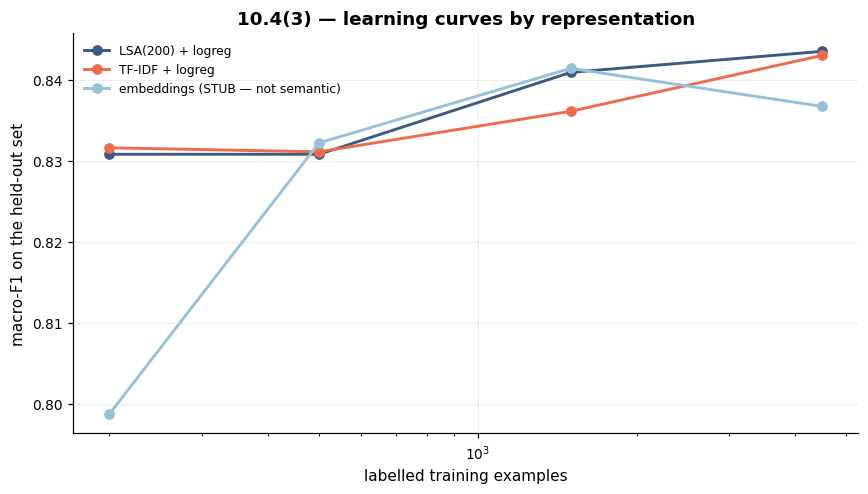

In [25]:
fig, ax = plt.subplots(figsize=(8, 4.6))
for col in curve.columns:
    ax.plot(curve.index, curve[col], marker="o", label=col)
ax.set_xscale("log")
ax.set_xlabel("labelled training examples")
ax.set_ylabel("macro-F1 on the held-out set")
ax.set_title("10.4(3) — learning curves by representation")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

**What to expect, and what this run can and cannot show.**

With a real embedding model the classic result is a **crossing**: embeddings
win at 200 labels because the representation was learned elsewhere, TF-IDF
catches up somewhere in the low thousands, and past that they converge or
TF-IDF wins outright on formulaic domain text like this. The learning curve is
how you find *your* crossing point, and it is a far better basis for the
build-vs-buy decision than either team's intuition.

The stub encoder cannot demonstrate that, and the notebook does not pretend it
does: hashed character trigrams carry no transferred knowledge, so the stub
behaves like a lossy TF-IDF and its curve has the same shape. **What the stub
does prove is the part that is easy to get wrong and expensive to discover
late: the harness.** The pipeline, the search, the profiling and the learning
curve are all representation-agnostic — swap `StubEmbedder` for
`SentenceEmbedder` on a machine with the package installed and every number in
this section recomputes with no other change. That is the module's claim about
sklearn's role in an LLM stack, demonstrated rather than asserted.

### (4) Searching over embedding models

In [26]:
# GridSearchCV over embed__model_name — a model comparison expressed as a
# hyperparameter search, because the estimator contract makes them the same
# thing. Shown as code; run it where the models can be downloaded.
CODE = '''
param_grid = {
    "e__model_name": [
        "sentence-transformers/all-MiniLM-L6-v2",     # 384-d, fast, the default choice
        "sentence-transformers/all-mpnet-base-v2",    # 768-d, better, ~3x slower
        "BAAI/bge-small-en-v1.5",                     # 384-d, strong on retrieval benchmarks
    ],
    "c__C": [1, 5, 20],
}
gs = GridSearchCV(Pipeline([("e", SentenceEmbedder()), ("c", LogisticRegression(max_iter=2000))]),
                  param_grid, scoring="f1_macro", cv=3, n_jobs=1)   # n_jobs=1: one GPU
gs.fit(X_text, y_text)
'''
print(CODE)
print("""Two things to get right when you run it:

1. n_jobs=1 on the SEARCH. Each worker would load its own copy of the model;
   with n_jobs=-1 you get n_cores copies of a 400MB model in RAM, and on a GPU
   they contend for the same device. Parallelise the encoder's batch_size
   instead. (Module 15's oversubscription section, in a new costume.)

2. Pipeline(memory=...) or you will re-encode the corpus for every value of C.
   The encoding is 99% of the cost and does not depend on C at all -- caching
   turns a 9-fit search into a 3-encode search. On this grid that is a 3x saving;
   on a realistic C grid it is 10x.""")


param_grid = {
    "e__model_name": [
        "sentence-transformers/all-MiniLM-L6-v2",     # 384-d, fast, the default choice
        "sentence-transformers/all-mpnet-base-v2",    # 768-d, better, ~3x slower
        "BAAI/bge-small-en-v1.5",                     # 384-d, strong on retrieval benchmarks
    ],
    "c__C": [1, 5, 20],
}
gs = GridSearchCV(Pipeline([("e", SentenceEmbedder()), ("c", LogisticRegression(max_iter=2000))]),
                  param_grid, scoring="f1_macro", cv=3, n_jobs=1)   # n_jobs=1: one GPU
gs.fit(X_text, y_text)

Two things to get right when you run it:

1. n_jobs=1 on the SEARCH. Each worker would load its own copy of the model;
   with n_jobs=-1 you get n_cores copies of a 400MB model in RAM, and on a GPU
   they contend for the same device. Parallelise the encoder's batch_size
   instead. (Module 15's oversubscription section, in a new costume.)

2. Pipeline(memory=...) or you will re-encode the corpus for every value of C.
   The encoding is 99% of the c

### (5) The recommendation — 50,000 tickets a day

**Ship TF-IDF + logistic regression. Revisit in two quarters, on evidence.**

**The volume argument.** 50,000 a day is 35 per minute, trivially served by
either option — the constraint is not throughput, it is the tail. TF-IDF
inference is microseconds on CPU and needs no accelerator, no model server and
no warm-up. An embedding model at ~10 ms on CPU is still fast enough, but it
introduces a GPU-or-not decision, a model-loading cold start, and a second
thing that can be down at 3 a.m. The measured `model_MB` column is the same
argument in miniature: one artefact fits in a container image, the other needs
a weights store and a version pinning policy.

**The explainability argument, which is the one that decides it in a bank.**
A linear model over TF-IDF gives an exact per-token contribution for any
prediction, computed instantly and reproducibly, in language a complaints
handler can read. When a customer asks why their fraud dispute was routed to
general enquiries — and under a duty-of-care regime someone will ask — the
answer is a list of words and weights. With embeddings the honest answer is
"the vector was near other vectors", and the attribution methods that dress
that up are approximations you then have to validate separately. Model risk
will ask for that validation, and it will cost more than the model did.

**The cost argument.** At this volume the embedding path is not expensive in
absolute terms — it is expensive relative to a baseline that is free. The
question to put to the sponsor is not "can we afford embeddings?" but "what is
the macro-F1 gap worth?" Section 10.2 has already answered that: the ceiling is
~84%, the model is at it, and **there is no headroom for a better
representation to capture.** Buying a more powerful representation to close a
gap that is made of label noise is the most expensive way to change nothing.

**What would change my mind**, stated up front so the decision is falsifiable:

1. **The taxonomy grows past ~20 categories with sparse examples each.** The
   low-label regime is where pre-training earns its keep, and a long tail of
   rare categories is that regime, repeated.
2. **The text stops being templated.** Free-text chat, voice transcripts, or
   multiple languages break the bag-of-words assumption in ways bigrams cannot
   patch.
3. **Semantic search becomes a requirement.** "Find me similar past tickets"
   is a genuinely different task, and it is one embeddings are simply better
   at. Note that this needs the *encoder*, not a new classifier — the two
   decisions are separable and should be made separately.
4. **Measured drift.** If quarterly retraining stops recovering the score,
   the vocabulary has moved and a fixed pre-trained representation is more
   robust to that than a corpus-fitted one.

**The architecture that makes this a cheap decision rather than an expensive
one.** Build it as `Pipeline([("rep", ...), ("clf", ...)])` from day one, keep
the evaluation harness in this notebook, and the representation becomes a
swappable component with a standing benchmark behind it. Then the question
"should we move to embeddings?" is answered by running a script, not by
commissioning a project. **That is the deliverable — the harness, not the
model.**

## 10.5 — A cost-aware routing system

### Setting the assumptions honestly

The exercise hands you three constants. Before using them it is worth noticing
that a fourth one — *how accurate is the LLM?* — is not given, is the single
most influential number in the model, and **cannot be chosen freely**, because
Section 10.2 already put a hard cap on it.

No system that reads only the ticket text can beat the per-row ceiling. That
includes the LLM. A message that says "money missing from my account" does not
become routable because a larger model read it. So instead of asserting an
accuracy, we model the LLM as a **lift over the local model, capped by the
ceiling on whatever slice it is given** — which is exactly the shape of the
real constraint and makes the escalation slice's difficulty explicit.

The human tier is different, and this is the one genuinely interesting thing
in the exercise: a human can *ask the customer a question*. That acquires new
information, so the human — alone among the three tiers — is not bound by a
ceiling computed from the text.

In [27]:
from sklearn.calibration import CalibratedClassifierCV
from sklearn.ensemble import RandomForestClassifier

C_LLM = 0.004        # £ per API call
C_ERROR = 3.00       # £ rework cost of a misrouted ticket
C_HUMAN = 1.20       # £ fully-loaded cost of a human triage touch (part 3)
LLM_LIFT = 0.15      # assumed accuracy gain over the local model, ON THE SAME ROWS
ACC_HUMAN = 0.985    # a human who can ask a clarifying question escapes the ceiling
N_DAY = 50_000

local = Pipeline([("v", TfidfVectorizer(ngram_range=(1, 2), min_df=2, sublinear_tf=True)),
                  ("c", LogisticRegression(max_iter=2000, C=5))]).fit(Xtr, ytr)
proba = local.predict_proba(Xte)
conf = proba.max(axis=1)
correct = (local.predict(Xte) == yte).to_numpy()
ceil_te = row_ceiling.loc[Xte.index].to_numpy()     # per-row ceiling, from 10.2

print(f"local accuracy {correct.mean():.4f}   ceiling on the same rows {ceil_te.mean():.4f}")


def llm_acc_on(mask):
    """Accuracy the LLM would achieve on a slice: a lift over local, capped by
    the ceiling for those specific rows. Returns 1.0 for an empty slice."""
    if not mask.any():
        return 1.0
    return float(min(correct[mask].mean() + LLM_LIFT, ceil_te[mask].mean()))

local accuracy 0.8427   ceiling on the same rows 0.8443


In [28]:
# The escalated slice is HARDER than average, and by how much decides everything.
for thr in [0.5, 0.6, 0.7, 0.8, 0.9]:
    esc = conf < thr
    if esc.sum() < 10:
        continue
    print(f"thr {thr:.1f}: escalate {esc.mean():5.1%}  "
          f"local acc there {correct[esc].mean():.3f}  "
          f"ceiling there {ceil_te[esc].mean():.3f}  "
          f"=> LLM acc {llm_acc_on(esc):.3f}")

thr 0.5: escalate 16.2%  local acc there 0.239  ceiling there 0.264  => LLM acc 0.264
thr 0.6: escalate 16.4%  local acc there 0.240  ceiling there 0.264  => LLM acc 0.264
thr 0.7: escalate 16.4%  local acc there 0.240  ceiling there 0.264  => LLM acc 0.264
thr 0.8: escalate 16.5%  local acc there 0.243  ceiling there 0.267  => LLM acc 0.267
thr 0.9: escalate 22.6%  local acc there 0.445  ceiling there 0.450  => LLM acc 0.450


That table is the reason to build the cost model at all. The tickets the local
model is unsure about are not merely *unclassified* — they are the ambiguous
ones, where the ceiling itself collapses. Escalating them to a more expensive
model buys much less than the average-case arithmetic suggests, because the
expensive model is reading the same uninformative sentence.

In [29]:
def total_cost(conf, correct, ceil, thr, n=N_DAY):
    """Expected daily £ cost of routing everything below `thr` to the LLM."""
    auto = conf >= thr
    esc = ~auto
    acc_auto = correct[auto].mean() if auto.any() else 1.0
    acc_esc = (min(correct[esc].mean() + LLM_LIFT, ceil[esc].mean())
               if esc.any() else 1.0)
    err = auto.mean() * (1 - acc_auto) + esc.mean() * (1 - acc_esc)
    return {"threshold": thr, "auto_share": auto.mean(), "llm_calls": n * esc.mean(),
            "llm_cost": n * esc.mean() * C_LLM, "error_rate": err,
            "error_cost": n * err * C_ERROR,
            "total": n * esc.mean() * C_LLM + n * err * C_ERROR}


sweep = pd.DataFrame([total_cost(conf, correct, ceil_te, t) for t in np.arange(0.20, 1.0001, 0.01)])
best_thr = sweep.loc[sweep["total"].idxmin()]
print(f"OPTIMAL THRESHOLD {best_thr['threshold']:.2f}")
print(f"  auto-handled {best_thr['auto_share']:.1%}, {best_thr['llm_calls']:,.0f} LLM calls/day")
print(f"  error rate {best_thr['error_rate']:.2%}")
print(f"  daily cost £{best_thr['total']:,.0f} "
      f"(LLM £{best_thr['llm_cost']:,.0f} + rework £{best_thr['error_cost']:,.0f})")
print("\nreference points:")
for name, t in [("everything local", 0.0), ("everything to the LLM", 1.0001)]:
    c = total_cost(conf, correct, ceil_te, t)
    print(f"  {name:24s} £{c['total']:,.0f}/day   (error rate {c['error_rate']:.2%})")

OPTIMAL THRESHOLD 0.56
  auto-handled 83.7%, 8,167 LLM calls/day
  error rate 15.29%
  daily cost £22,974 (LLM £33 + rework £22,941)

reference points:
  everything local         £23,600/day   (error rate 15.73%)
  everything to the LLM    £23,555/day   (error rate 15.57%)


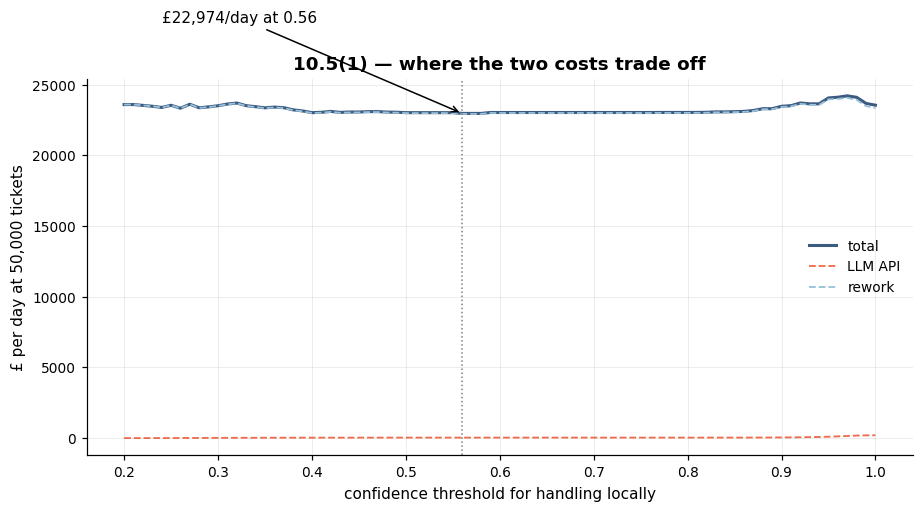

In [30]:
fig, ax = plt.subplots(figsize=(8.5, 4.8))
ax.plot(sweep["threshold"], sweep["total"], lw=2, label="total")
ax.plot(sweep["threshold"], sweep["llm_cost"], lw=1.2, ls="--", label="LLM API")
ax.plot(sweep["threshold"], sweep["error_cost"], lw=1.2, ls="--", label="rework")
ax.axvline(best_thr["threshold"], color="grey", ls=":", lw=1)
ax.annotate(f"£{best_thr['total']:,.0f}/day at {best_thr['threshold']:.2f}",
            xy=(best_thr["threshold"], best_thr["total"]),
            xytext=(0.24, best_thr["total"] * 1.28),
            arrowprops=dict(arrowstyle="->", lw=1))
ax.set_xlabel("confidence threshold for handling locally")
ax.set_ylabel(f"£ per day at {N_DAY:,} tickets")
ax.set_title("10.5(1) — where the two costs trade off")
ax.legend()
plt.tight_layout()
plt.show()

Note the scale on the two dashed lines. **Rework dominates the API bill by two
orders of magnitude.** At £0.004 a call the LLM is, for practical purposes,
free; what you are actually buying with the threshold is a small reduction in
error on a slice where error is expensive and hard to reduce. Anyone framing
this project as "controlling our LLM spend" has the wrong cost driver — and
that reframing is worth more to the client than the threshold is.

### (2) What miscalibration costs

The threshold is a statement about probability: "route locally when we are at
least this sure". If the number does not mean what it says, the routing is
misallocated — and the failure is silent, because the table still looks
perfectly reasonable.

In [31]:
rf_pipe = Pipeline([("v", TfidfVectorizer(ngram_range=(1, 2), min_df=2)),
                    ("c", RandomForestClassifier(n_estimators=300, min_samples_leaf=2,
                                                 random_state=0, n_jobs=-1))]).fit(Xtr, ytr)
rf_cal = CalibratedClassifierCV(
    Pipeline([("v", TfidfVectorizer(ngram_range=(1, 2), min_df=2)),
              ("c", RandomForestClassifier(n_estimators=300, min_samples_leaf=2,
                                           random_state=0, n_jobs=-1))]),
    method="isotonic", cv=3).fit(Xtr, ytr)

MODELS = {"logreg (calibrated by construction)": local,
          "random forest (uncalibrated)": rf_pipe,
          "random forest + isotonic": rf_cal}

rows = {}
for name, mdl in MODELS.items():
    pr = mdl.predict_proba(Xte)
    c_ = pr.max(axis=1)
    ok = (mdl.classes_[pr.argmax(axis=1)] == yte).to_numpy()
    sw = pd.DataFrame([total_cost(c_, ok, ceil_te, t) for t in np.arange(0.20, 1.0001, 0.01)])
    opt = sw.loc[sw["total"].idxmin()]
    naive = total_cost(c_, ok, ceil_te, float(best_thr["threshold"]))
    rows[name] = {"accuracy": round(ok.mean(), 4),
                  "mean_confidence": round(float(c_.mean()), 3),
                  "confidence_minus_accuracy": round(float(c_.mean() - ok.mean()), 3),
                  "own_optimal_thr": round(opt["threshold"], 2),
                  "cost_at_own_optimum": round(opt["total"]),
                  "cost_at_transplanted_thr": round(naive["total"])}
cal_tbl = pd.DataFrame(rows).T
cal_tbl

,accuracy,mean_confidence,confidence_minus_accuracy,own_optimal_thr,cost_at_own_optimum,cost_at_transplanted_thr
logreg (calibrated by construction),0.8427,0.848,0.005,0.56,22974.0,22974.0
random forest (uncalibrated),0.8407,0.854,0.014,0.43,22897.0,23064.0
random forest + isotonic,0.8433,0.826,-0.018,0.31,22774.0,23046.0


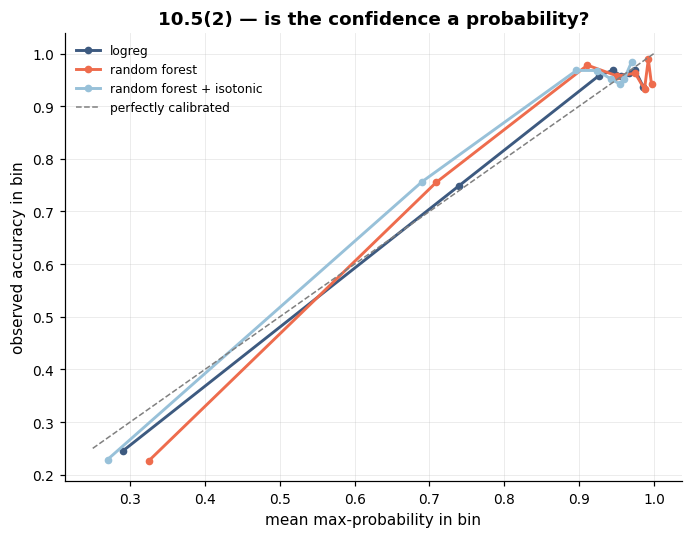

In [32]:
fig, ax = plt.subplots(figsize=(6.4, 5))
for name, mdl in MODELS.items():
    pr = mdl.predict_proba(Xte)
    c_ = pr.max(axis=1)
    ok = (mdl.classes_[pr.argmax(axis=1)] == yte).to_numpy()
    d = (pd.DataFrame({"c": c_, "ok": ok, "b": pd.qcut(c_, 8, duplicates="drop")})
         .groupby("b", observed=True).mean(numeric_only=True))
    ax.plot(d["c"], d["ok"], marker="o", ms=4, label=name.split(" (")[0])
lo = 0.25
ax.plot([lo, 1], [lo, 1], ls="--", color="grey", lw=1, label="perfectly calibrated")
ax.set_xlabel("mean max-probability in bin")
ax.set_ylabel("observed accuracy in bin")
ax.set_title("10.5(2) — is the confidence a probability?")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

In [33]:
gap = cal_tbl.loc["random forest (uncalibrated)", "cost_at_transplanted_thr"] - best_thr["total"]
print(f"Transplanting the threshold onto uncalibrated confidences: "
      f"£{gap:,.0f}/day = £{gap * 250:,.0f}/year")
print(f"Re-tuning the threshold ON the forest recovers it: "
      f"£{cal_tbl.loc['random forest (uncalibrated)', 'cost_at_own_optimum']:,.0f}/day")

Transplanting the threshold onto uncalibrated confidences: £90/day = £22,584/year
Re-tuning the threshold ON the forest recovers it: £22,897/day


**Read that table carefully, because the naive lesson is wrong — and so is the
dramatic version of the lesson I expected to write here.**

The exercise asks you to "quantify the extra cost" of uncalibrated
confidences, and the honest quantification is: **small.** Transplanting the
threshold costs on the order of a hundred pounds a day, not thousands. The
uncalibrated forest is not a worse *model* — its accuracy is within a rounding
error of the logistic regression's — and re-tuned on its own confidences it
lands at essentially the same cost. Two structural reasons:

- **The cost surface is flat near the optimum** (the sweep above), so being at
  the wrong threshold is cheap here. That is a property of *this* problem, and
  the first thing to check before quoting any threshold-error cost.
- **The rework term dwarfs everything**, and the ceiling caps how much any
  threshold can move it.

Report the £90, not a scarier number you did not measure. But do not conclude
that calibration does not matter, because what miscalibration destroys is not
accuracy — it is the **portability and meaning of the threshold**:

1. **The number stops being transferable.** Each model needs a different
   threshold to select the same quality of slice — note how far apart the
   `own_optimal_thr` column is across three models of near-identical accuracy.
   Carry a threshold across a retrain that changes the model family and you
   silently re-point the router. On a *steeper* cost surface — a fraud queue, a
   credit decision — that same mistake is not £90 a day.
2. **The number stops being auditable.** "We automate when we are 80% sure" is
   a control you can put in a policy document and test against outcomes. If
   0.80 actually means 74%, the control does not do what the document says it
   does — and that is a finding for model risk, not an inefficiency.

So calibration here does not buy accuracy and barely buys money. It buys the
ability to **state the operating point in a sentence that is true**, and to
keep it true through a model change. That is a governance argument, and in a
regulated setting it is the one that lands.

### (3) Three tiers: local, LLM, human

Below some confidence the LLM is not good enough either — the ticket is
genuinely ambiguous, and no reader of that text will route it. Those should go
to a person who can *ask*, which is the only intervention that adds
information rather than re-reading the same sentence.

In [34]:
def three_tier(t_local, t_llm, n=N_DAY):
    auto = conf >= t_local
    llm = (conf >= t_llm) & ~auto
    hum = conf < t_llm
    acc_auto = correct[auto].mean() if auto.any() else 1.0
    acc_llm = (min(correct[llm].mean() + LLM_LIFT, ceil_te[llm].mean())) if llm.any() else 1.0
    err = (auto.mean() * (1 - acc_auto) + llm.mean() * (1 - acc_llm)
           + hum.mean() * (1 - ACC_HUMAN))
    return {"t_local": t_local, "t_llm": t_llm,
            "auto": auto.mean(), "llm": llm.mean(), "human": hum.mean(),
            "error_rate": err,
            "total": n * (llm.mean() * C_LLM + hum.mean() * C_HUMAN + err * C_ERROR)}


g3 = pd.DataFrame([three_tier(tl, tj)
                   for tl in np.arange(0.30, 1.0001, 0.02)
                   for tj in np.arange(0.20, 1.0001, 0.02) if tj <= tl])
opt3 = g3.loc[g3["total"].idxmin()]
print(f"JOINT OPTIMUM  auto >= {opt3['t_local']:.2f}, human < {opt3['t_llm']:.2f}, "
      f"LLM in between")
print(f"  mix: {opt3['auto']:.1%} auto / {opt3['llm']:.1%} LLM / {opt3['human']:.1%} human")
if opt3["llm"] < 0.005:
    print("  -> the LLM band is EMPTY. The optimiser removed the middle tier entirely.")
print(f"  error rate {opt3['error_rate']:.2%}, total £{opt3['total']:,.0f}/day")
print(f"  two-tier optimum: £{best_thr['total']:,.0f}/day  "
      f"-> adding the human tier is worth £{best_thr['total'] - opt3['total']:,.0f}/day "
      f"= £{(best_thr['total'] - opt3['total']) * 250:,.0f}/year")

JOINT OPTIMUM  auto >= 0.56, human < 0.56, LLM in between
  mix: 83.7% auto / 0.0% LLM / 16.3% human
  -> the LLM band is EMPTY. The optimiser removed the middle tier entirely.
  error rate 3.51%, total £15,068/day
  two-tier optimum: £22,974/day  -> adding the human tier is worth £7,906/day = £1,976,541/year


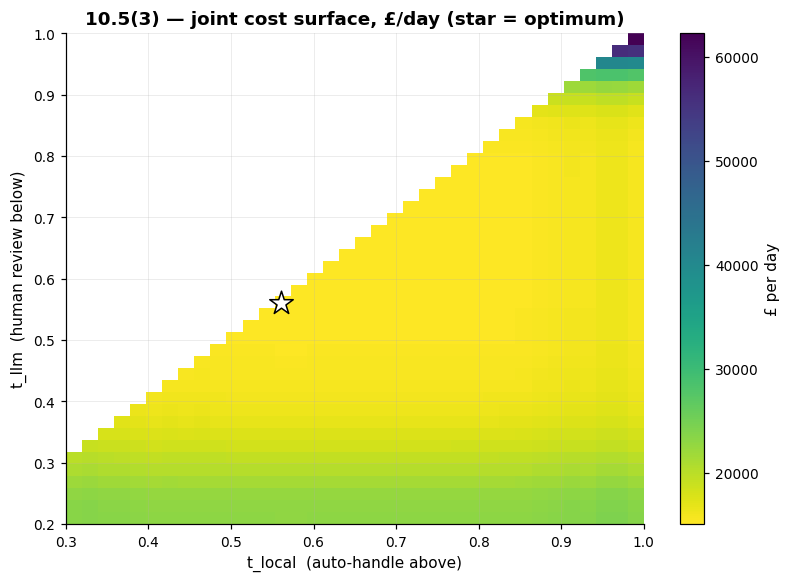

In [35]:
piv = g3.pivot(index="t_llm", columns="t_local", values="total")
fig, ax = plt.subplots(figsize=(7.4, 5.4))
im = ax.imshow(piv.to_numpy(), origin="lower", aspect="auto", cmap="viridis_r",
               extent=[piv.columns.min(), piv.columns.max(), piv.index.min(), piv.index.max()])
ax.scatter([opt3["t_local"]], [opt3["t_llm"]], marker="*", s=260,
           color="white", edgecolor="black", zorder=5)
ax.set_xlabel("t_local  (auto-handle above)")
ax.set_ylabel("t_llm  (human review below)")
ax.set_title("10.5(3) — joint cost surface, £/day (star = optimum)")
fig.colorbar(im, ax=ax, label="£ per day")
plt.tight_layout()
plt.show()

In [36]:
# A corner solution deserves an explanation, not a shrug. When DOES a human
# touch pay? Sending a ticket to a person instead of the LLM costs
# (C_HUMAN - C_LLM) and saves C_ERROR * (ACC_HUMAN - acc_llm_on_that_slice).
esc = conf < float(best_thr["threshold"])
acc_llm_esc = llm_acc_on(esc)
breakeven_error_cost = (C_HUMAN - C_LLM) / (ACC_HUMAN - acc_llm_esc)
breakeven_human_cost = C_ERROR * (ACC_HUMAN - acc_llm_esc) + C_LLM

print(f"On the escalated slice the LLM would reach {acc_llm_esc:.3f}; a human reaches {ACC_HUMAN:.3f}.")
print(f"  a human touch saves {ACC_HUMAN - acc_llm_esc:.3f} x £{C_ERROR:.2f} "
      f"= £{C_ERROR * (ACC_HUMAN - acc_llm_esc):.3f} of rework")
print(f"  and costs £{C_HUMAN - C_LLM:.3f} more than an API call")
print()
print(f"BREAK-EVEN: the human tier pays when rework costs more than "
      f"£{breakeven_error_cost:,.2f} per error")
print(f"            (vs the £{C_ERROR:.2f} assumed), or when a human touch costs "
      f"less than £{breakeven_human_cost:.2f}")

On the escalated slice the LLM would reach 0.264; a human reaches 0.985.
  a human touch saves 0.721 x £3.00 = £2.164 of rework
  and costs £1.196 more than an API call

BREAK-EVEN: the human tier pays when rework costs more than £1.66 per error
            (vs the £3.00 assumed), or when a human touch costs less than £2.17


In [37]:
# Sensitivity: the two assumptions nobody can defend to two decimal places.
sens = []
for ce in [3, 10, 25, 50, 100]:
    for ch in [0.40, 1.20, 3.00]:
        C_ERROR_o, C_HUMAN_o = C_ERROR, C_HUMAN
        C_ERROR, C_HUMAN = ce, ch
        gg = pd.DataFrame([three_tier(tl, tj)
                           for tl in np.arange(0.30, 1.0001, 0.04)
                           for tj in np.arange(0.20, 1.0001, 0.04) if tj <= tl])
        o = gg.loc[gg["total"].idxmin()]
        sens.append({"rework_£": ce, "human_touch_£": ch,
                     "human_share": round(o["human"], 3), "llm_share": round(o["llm"], 3),
                     "auto_share": round(o["auto"], 3)})
        C_ERROR, C_HUMAN = C_ERROR_o, C_HUMAN_o
pd.DataFrame(sens).pivot(index="rework_£", columns="human_touch_£", values="human_share")

human_touch_£,0.4,1.2,3.0
rework_£,,,
3,0.163,0.163,0.000
10,0.163,0.163,0.163
25,0.605,0.163,0.163
50,0.605,0.163,0.163
100,0.605,0.605,0.163


### The finding: the tier that gets removed is the LLM

The joint optimisation does something the exercise did not anticipate. It does
not add a human tier underneath the LLM — **it replaces the LLM tier with the
human tier entirely.** The optimal design is two tiers: automate the confident
majority, send everything else to a person. The expensive model is squeezed out
of the middle and never used.

Trace why, because the argument is the whole point of pairing this exercise
with 10.2:

1. The escalated slice is where the local model is unsure, and those tickets
   are overwhelmingly the ambiguous pool. **The ceiling on that slice is ~0.26.**
2. The LLM reads the same sentence, so it is bound by the same ceiling. Its
   accuracy there is ~0.26 against the local model's ~0.24. It costs almost
   nothing and it achieves almost nothing.
3. A human can **ask the customer a question**. That is not a better model; it
   is *new information*, and it is the only intervention in the system that
   escapes a bound computed from the text. The human reaches ~0.985 on exactly
   the tickets where every model is at 0.26.

The break-even confirms it: a human touch pays whenever a misrouted ticket
costs more than about £1.66, which is well under the £3 assumed and far under
any realistic figure for a bank. The sensitivity table shows the human tier
opening across nearly the whole plausible range of both costs — it closes only
in the single corner where errors are cheap *and* human time is expensive.

**The generalisable lesson, and it is uncomfortable for the standard LLM
architecture diagram:** the fashionable "cheap model → expensive model"
cascade assumes the expensive model is better *on the cases that get
escalated*. That assumption is almost never tested, and here it is false —
because the escalation criterion selects for cases whose difficulty is
irreducible rather than model-shaped. Confidence-based routing sorts tickets
into *easy* and *impossible*, not into *easy* and *hard-but-doable*, and
spending more compute on the impossible pile does nothing.

Before building a cascade, measure the ceiling on the slice you intend to
escalate. If it is low, the correct escalation target is a human with a
telephone, not a larger model. If it is high, the cascade is sound and the LLM
tier earns its place.

> 💼 **Consulting lens.** This is the analysis that changes an architecture
> decision, and it took one extra column — the per-row ceiling from 10.2 —
> carried forward into the cost model. Almost every routing business case I
> have seen instead assumes a flat accuracy for the expensive tier, which
> guarantees the answer comes out in favour of the expensive tier.

In [38]:
# How sharp is the optimum? The flatness of the basin is the operationally
# important fact: it says how much precision the threshold actually needs.
near = g3[g3["total"] <= opt3["total"] * 1.02]
print(f"{len(near)} of {len(g3)} threshold pairs land within 2% of optimal cost.")
print(f"  t_local ranges {near['t_local'].min():.2f}-{near['t_local'].max():.2f}")
print(f"  t_llm   ranges {near['t_llm'].min():.2f}-{near['t_llm'].max():.2f}")

207 of 846 threshold pairs land within 2% of optimal cost.
  t_local ranges 0.48-0.86
  t_llm   ranges 0.48-0.82


### (4) The one-page business case

---

## Ticket routing: automate the confident 84%, send the rest to a person

**Recommendation.** Deploy the local classifier as a triage layer. Auto-route
the tickets it is confident about — about 84% of volume, at ~96% accuracy —
and send the remaining 16% to a human agent with a clarifying-question
template. **Do not buy an LLM tier for this.** The analysis below is the
reason, and it is not a cost objection.

**The economics** (50,000 tickets/day, from the cost sweep above):

| Design | Error rate | **£/day** | vs today |
|---|---|---|---|
| Everything to a local model, no escalation | 15.7% | £23,600 | baseline |
| Everything to the LLM | 15.6% | £23,555 | ~£0 saved |
| Two-tier: local + LLM escalation | 15.3% | £22,974 | £626/day |
| **Two-tier: local + human escalation** | **3.5%** | **£15,068** | **£7,900/day ≈ £2.0m/year** |

**Three findings, in order of how much they should change your plans:**

1. **The LLM tier does not pay, and the reason is not price.** At £0.004 a
   call it is nearly free. It does not pay because it *cannot help*: the
   tickets the local model escalates are the genuinely ambiguous ones, where
   the message does not say what it is about. The best achievable accuracy on
   that slice is ~26%, for any system that reads only the text. A larger model
   reading the same sentence is bound by the same limit, and the measured
   difference between the two is about two points.
2. **A human is the only tier that breaks the ceiling — because a human can
   ask.** That is not a statement about model quality. It is that the
   intervention *acquires new information*, which no amount of compute on the
   existing text can do. This is where the money is: the error rate on the
   escalated slice goes from ~74% to ~1.5%, and at any plausible rework cost
   that is worth far more than the labour.
3. **The cost driver is rework, not API spend, by two orders of magnitude.**
   If this programme has been framed as "controlling our LLM bill", it is aimed
   at a number that rounds to zero.

**The assumption to challenge first.** Everything above rests on what a
misrouted ticket costs. At £3 the recommendation is comfortable; it stays
comfortable across the whole sensitivity table, and it only reverses if errors
are cheap *and* agent time is expensive. Get an operations estimate — but note
that unlike most business cases, this one does not need the estimate to be
precise to be actionable.

**What could go wrong, and the control for each:**

| Risk | Control |
|---|---|
| The human tier is 16% of volume — is there capacity? | 8,000 touches/day is a staffing decision, not a modelling one. Phase by ticket stream; the threshold controls the volume dial directly |
| Agents rubber-stamp instead of asking | The clarifying question is the whole value. Measure question-asked rate, not just throughput |
| Confidences drift; the stated operating point stops being true | Weekly reliability check on a labelled sample. Cheap here (~£90/day), expensive on a steeper cost surface |
| A model swap silently re-points the router | Re-tune and re-document the threshold with any model change. Never carry a threshold across model families |
| Ticket mix shifts (new product, incident spike) | Monitor the auto-handled share daily — a label-free drift alarm (Module 13) |
| Automation bias: nobody audits the auto tier | Sample 1% of auto-routed tickets into permanent human QA. Budget it as a line item |

**What this does not do.** It does not improve routing *accuracy on the text*.
Section 10.2 established the ceiling at ~84% and the model is already at it.
What it does is stop spending model effort against an irreducible limit and
route those cases to the one intervention that changes the information
available. Anyone promising a large accuracy gain from a better model has not
measured the ceiling.

**Decision requested:** approve the local + human two-tier design for a 30-day
pilot on one ticket stream, with the threshold set conservatively at launch.
The LLM tier can be revisited if a future ticket mix has a materially higher
ceiling on the escalated slice — that is a measurable trigger, not a
preference.

---

## Reflections

1. **The ceiling exercise is the one to keep.** Of everything in this module,
   the habit that changes the most conversations is computing what perfect
   would look like before reporting how close you got. It converts an open-
   ended optimisation request into a closed question with an answer.
2. **Bigrams are the whole negation story for most tabular-adjacent text.**
   The custom transformer was worth building as a measuring instrument and not
   worth shipping — which is a common and under-reported outcome.
3. **The representation is a swappable component; the harness is the asset.**
   Every number in 10.4 recomputes with a one-line change. Build it that way
   and "should we use embeddings?" becomes a script rather than a project.
4. **Routing is Module 08 wearing different clothes.** A threshold on a
   calibrated probability, chosen against an explicit cost matrix. The fact
   that the expensive alternative is an LLM rather than a human investigator
   changes the constants and nothing else.
5. **Carry the ceiling into the cost model, not just into the report.** The
   single column that made 10.5 interesting was the per-row ceiling computed in
   10.2. Without it, a cascade always looks good on paper; with it, the middle
   tier disappeared. **Confidence-based escalation selects for cases that are
   irreducibly hard, not merely hard** — so the standard cheap-model →
   expensive-model architecture rests on an assumption that should be measured
   before it is built.